In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# ============================================================================
# 1. BIMODAL EXPERT DATA (Obstacle Avoidance)
# ============================================================================
N_samples = 2000
# State is always 0 (approaching obstacle)
x_train = torch.zeros(N_samples, 1)

# Expert randomly chooses left (-2.0) or right (+2.0)
choices = torch.randint(0, 2, (N_samples, 1)).float()
u_expert = torch.where(choices == 0, torch.tensor(-2.0), torch.tensor(2.0))

In [3]:
# ============================================================================
# 2. DIFFUSION PROCESS SCHEDULE (Linear Noise Schedule)
# ============================================================================
T_steps = 50
beta_start, beta_end = 1e-4, 0.05
betas = torch.linspace(beta_start, beta_end, T_steps)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [5]:
# ============================================================================
# 3. DIFFUSION POLICY NETWORK (Score Estimator)
# ============================================================================
class DiffusionPolicyNet(nn.Module):
    def __init__(self):
        super(DiffusionPolicyNet, self).__init__()
        # Input: state (1) + noisy_action (1) + time_step (1) = 3
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Predicts the added noise \epsilon
        )

    def forward(self, x, a, t_norm):
        # Concatenate inputs
        inputs = torch.cat([x, a, t_norm], dim=1)
        return self.net(inputs)

In [ ]:
policy = DiffusionPolicyNet()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)
# ============================================================================
# 4. TRAINING LOOP (Maximizing Log-Likelihood via Denoising)
# ============================================================================
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Sample random time steps for the batch
    t = torch.randint(0, T_steps, (N_samples, 1))
    
    # 2. Extract corresponding noise variances
    alpha_cumprod_t = alphas_cumprod[t]
    
    # 3. Add process noise to expert actions (Forward SDE)
    noise = torch.randn_like(u_expert)
    noisy_action = torch.sqrt(alpha_cumprod_t) * u_expert + torch.sqrt(1 - alpha_cumprod_t) * noise
    
    # Normalize time for neural network stability [-1, 1]
    t_norm = (t.float() / T_steps) * 2.0 - 1.0
    
    # 4. Neural Network predicts the noise that was added
    predicted_noise = policy(x_train, noisy_action, t_norm)
    
    # 5. Loss: Difference between actual noise and predicted noise
    # This is mathematically proportional to the score matching objective -> equivalent to maximizing log-likelihood of the expert actions
    # This is called denoising score matching in the diffusion literature
    loss = nn.MSELoss()(predicted_noise, noise)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")

print("Diffusion Training Finished.\n")

/home/luky/.local/lib/python3.10/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch    0 | Loss: 0.9391
Epoch  200 | Loss: 0.2320
Epoch  400 | Loss: 0.2222
Epoch  600 | Loss: 0.1588
Epoch  800 | Loss: 0.1702
Diffusion Training Finished.



In [8]:
# ============================================================================
# 5. INFERENCE (Reverse SDE / Denoising Loop)
# ============================================================================
policy.eval()

def sample_diffusion_action(state, num_samples=1000):
    with torch.no_grad():
        # 1. Start with pure Gaussian noise a_T ~ N(0, I)
        a_k = torch.randn(num_samples, 1)
        x_k = state.repeat(num_samples, 1)
        
        # 2. Iteratively denoise from T down to 0 (Feedback control loop)
        for k in reversed(range(T_steps)):
            t_tensor = torch.full((num_samples, 1), k)
            t_norm = (t_tensor.float() / T_steps) * 2.0 - 1.0
            
            # Predict noise
            pred_noise = policy(x_k, a_k, t_norm)
            
            # Euler-Maruyama step (reverse process)
            alpha_k = alphas[k]
            alpha_cumprod_k = alphas_cumprod[k]
            
            # Reconstruct action
            a_k = (1 / torch.sqrt(alpha_k)) * (a_k - ((1 - alpha_k) / torch.sqrt(1 - alpha_cumprod_k)) * pred_noise)
            
            # Add Langevin noise if not the last step
            if k > 0:
                z = torch.randn_like(a_k)
                a_k = a_k + torch.sqrt(betas[k]) * z
                
    return a_k

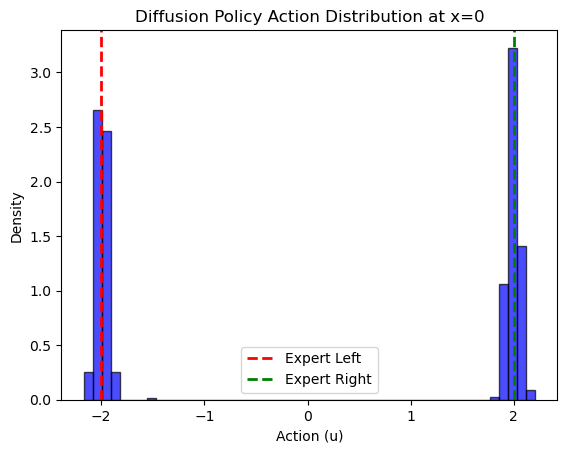

In [9]:
# Test the policy on the obstacle state (x=0)
test_state = torch.tensor([[0.0]])
sampled_actions = sample_diffusion_action(test_state).numpy()

# Plot the distribution of sampled actions
plt.hist(sampled_actions, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(-2.0, color='red', linestyle='dashed', linewidth=2, label='Expert Left')
plt.axvline(2.0, color='green', linestyle='dashed', linewidth=2, label='Expert Right')
plt.title('Diffusion Policy Action Distribution at x=0')
plt.xlabel('Action (u)')
plt.ylabel('Density')
plt.legend()
plt.show()